# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 65     |  |
| :-------------|:-------------|
| Koen Gort| 6574963 |
| Jasper Bom| 6295835 |

In [38]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

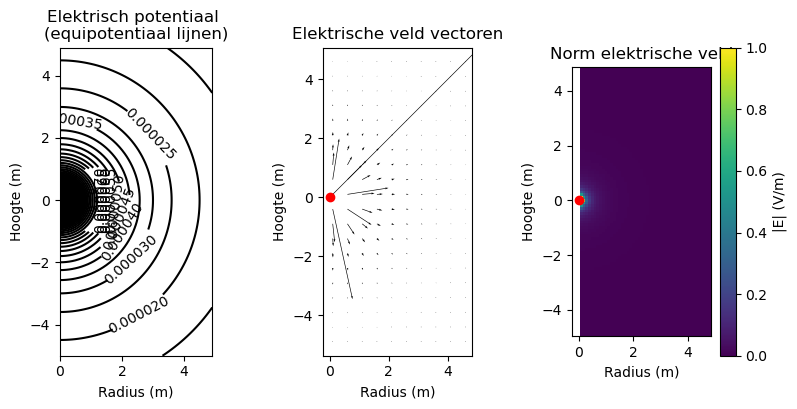

In [39]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

De index die correspondeert met z = 0 is: 50.


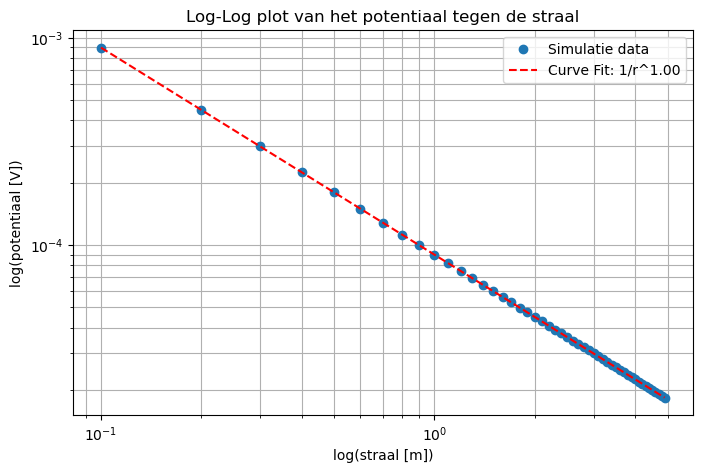

De berekende exponent (a) via curve_fit is: 1.0000


In [42]:
# 1. Bepaal welke index correspondeert met z = 0 m.
# De onderstaande functie vindt de index die het dichst bij het absolute minimum van z ligt, dus waar z 0 is.
index_z0 = np.argmin(np.abs(z))
print('De index die correspondeert met z = 0 is: {}.' .format(index_z0))

# 2. Plot de log van het potentiaal tegen de log van de straal
# Het potentiaal op de lijn z = 0. 
# Negeren ven het eerste punt om delen door 0 te voorkomen.
r_plot = r[1:]
V_z0 = V[index_z0, 1:] #alleen de data van de hoogte waar z = 0 m.

# Plotten van deze gegevens
plt.figure(figsize=(8, 5))
plt.loglog(r_plot, V_z0, 'o', label='Simulatie data')
plt.xlabel('log(straal [m])')
plt.ylabel('log(potentiaal [V])')
plt.title('Log-Log plot van het potentiaal tegen de straal')
plt.grid(True, which="both")


# 3. Fit de log van het potentiaal met de log van de straal

from scipy.optimize import curve_fit

# Theoretisch verwachte functie
# V = q/(4pi*e_0) * 1/r
# r is de variabele, C en a zijn de parameters die de computer moet vinden 
def machtsfunctie(r, C, a): 
    return C / (r**a)

# Functiefit op de orginele data

popt, pcov = curve_fit(machtsfunctie, r_plot, V_z0)

C_fit, a_fit = popt

# Plotten van de functiefit

plt.plot(r_plot, machtsfunctie(r_plot, *popt), 'r--', label=f'Curve Fit: 1/r^{a_fit:.2f}')
plt.legend()
plt.show()


# 4. Print het exponent op een nette manier.
print(f"De berekende exponent (a) via curve_fit is: {a_fit:.4f}")


##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

24


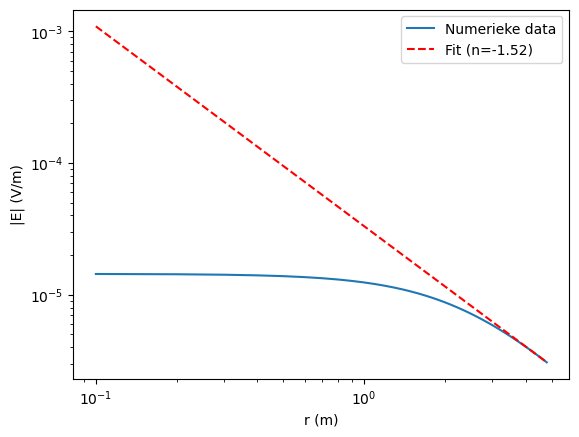

In [44]:
from scipy.optimize import curve_fit
def E_feld(log_r, log_a, n):  # met het idee dat E a*r^n is vandaar de n die je uit de log kan halen.
    return log_a + n * log_r

#neem midden        
mid_z = normE.shape[1] // 2
print(mid_z)

mask = r_for_E > 4 # alleen het op grote afstand gedraagt de lading zig als een puntlading, die punten wil je meenemen niet de eerste punten.
log_r_fit = np.log(r_for_E[mask])
log_E_fit = np.log(normE[mid_z, :][mask])

#curve fit
popt, pcov = curve_fit(E_feld, log_r_fit, log_E_fit)
log_a_fit, n_fit = popt
a_fit = np.exp(log_a_fit)

E_fit_volledig = a_fit * (r_for_E**n_fit)

plt.figure()
plt.plot(r_for_E, normE[mid_z, :], label="Numerieke data")
plt.plot(r_for_E, E_fit_volledig, "r--", label=f"Fit (n={n_fit:.2f})") 

plt.xscale("log")
plt.yscale("log")
plt.xlabel("r (m)")
plt.ylabel("|E| (V/m)")
plt.legend()
plt.show()




### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [85]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 10  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

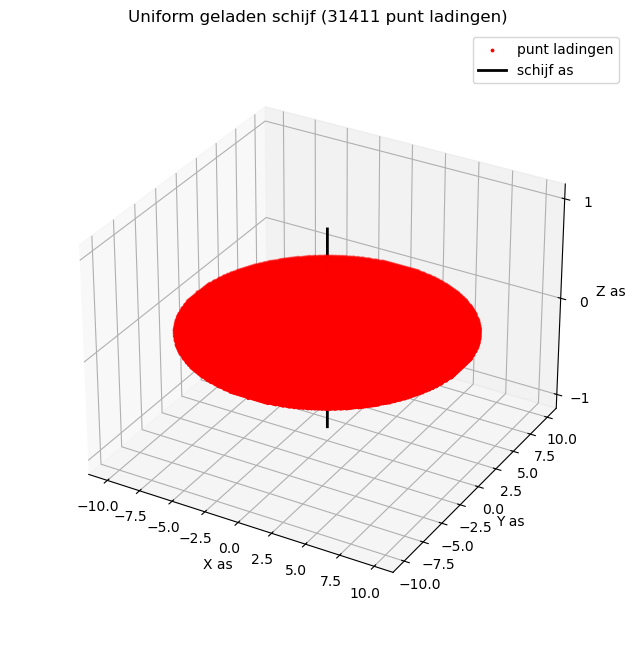

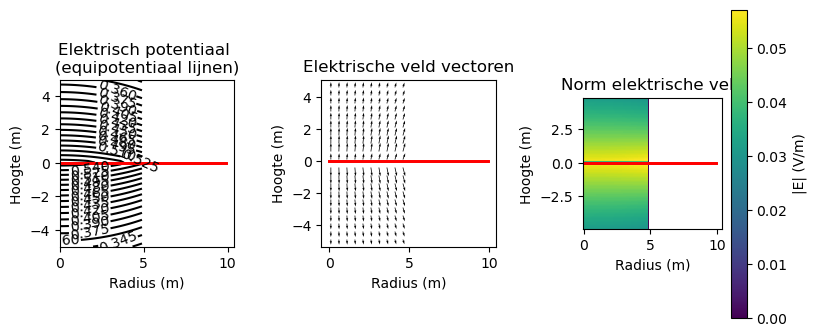

In [86]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. Deze geeft de straal van de schijf. Dan verdwijnt de schijf en dus het geladen veld.
2. Deze geeft de afstand tussen de ladingen aan, hoe groter de gridstep, hoe minder ladingen er over het oppervlak verdeeld worden.
3. "z_coord_DISK" geeft de hoogte van de schijf aan. Als je deze variabele veranderd veranderd de hoogte van het elektrisch veld.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [82]:
ladingsdichtheid = inter_charge_distance*charge_one_point/(np.pi*disk_radius**2)

print(f"De ladingsdichtheid is: {ladingsdichtheid:.2e} C/m^2")

De ladingsdichtheid is: 3.54e-17 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

50


Text(0.5, 0, 'Straal r (m)')

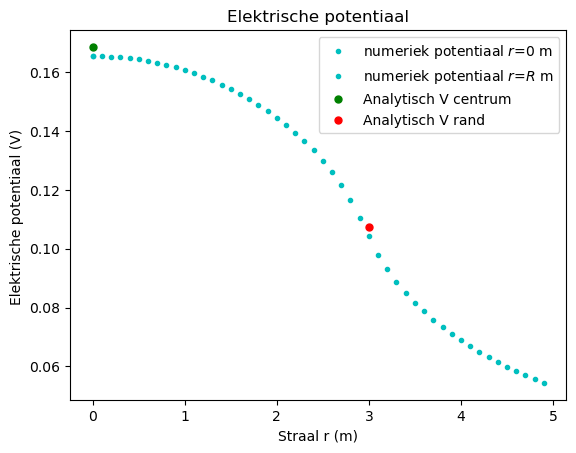

In [70]:
sigma = number_point_charges_on_disk*charge_one_point/(np.pi*disk_radius**2)
idx_z_zero = np.argmin(np.abs(z))
print(idx_z_zero)
R = disk_radius
V_0 = V[idx_z_zero, 0]
V_center = sigma*disk_radius / (2*epsilon0)      # potentiaal in centrum
V_edge   = sigma*disk_radius / (np.pi*epsilon0)  # potentiaal aan rand
V_R =  V[idx_z_zero, :]
r_R =  r

plt.title(f"Elektrische potentiaal")
#plt.plot(r, V, "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "c.", label="numeriek potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", label="numeriek potentiaal $r$=$R$ m")
plt.plot(0, V_center, 'g.', markersize=10, label='Analytisch V centrum')
plt.plot(disk_radius, V_edge, 'r.', markersize=10, label='Analytisch V rand')
plt.legend()
plt.ylabel("Elektrische potentiaal (V) ")
plt.xlabel("Straal r (m)")

#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


0


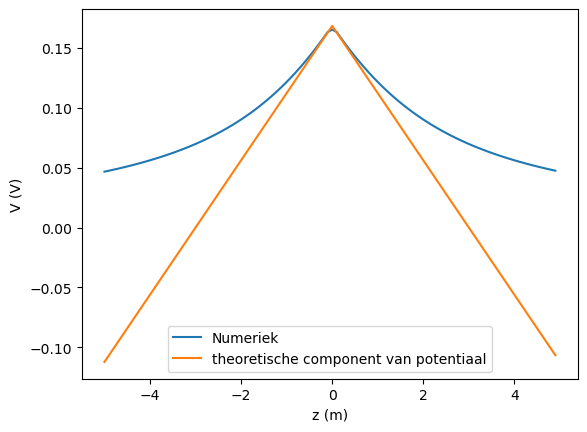

In [ ]:
#mid_r = V.shape[0] // 2
mid_r = np.argmin(np.abs(r))
print(mid_r)
R = disk_radius
V_z = V[:, mid_r] 

def grootPot(z):
    return (sigma/(2*epsilon0)) * (R - np.abs(z))


plt.figure()
plt.plot(z,V_z, label="Numeriek")
plt.plot(z,grootPot(z), label="theoretische component van potentiaal")
plt.xlabel("z (m)")
plt.ylabel("E (V/m)")
plt.legend()
plt.savefig("theoretische_potenciaal_R3.png", dpi=300)

plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

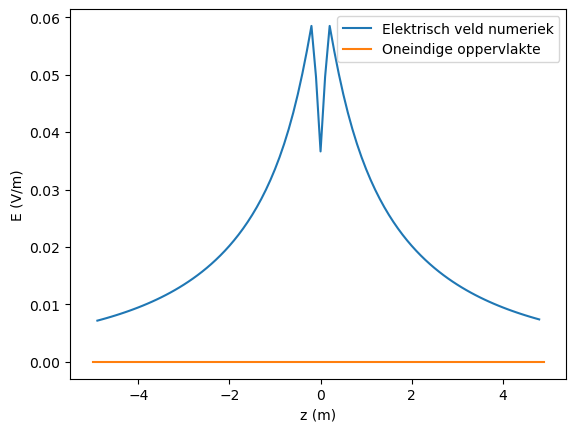

In [ ]:
mid_z = normE.shape[1] // 2
Eoneindig = ladingsdichtheid/(2*epsilon0)
Eoneindig_array =np.array([])

E_z_on = np.linspace(min(z),max(z),1000)
Eoneindig_array = np.full(len(E_z_on), Eoneindig)


E_z = normE[:, mid_z] 

plt.plot(z_for_E,E_z,label="Elektrisch veld numeriek")
plt.plot(E_z_on,Eoneindig_array,label="Oneindige oppervlakte")
plt.xlabel("z (m)")
plt.ylabel("E (V/m)")
plt.legend()
plt.savefig("theoretische_potenciaal_R3_plaat.png", dpi=300)
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. Hoe groter de z waarde in zowel positieve als negatieve richting, hoe dichter ze elkaar benaderen
2. Je ziet dat naarmaatte de z waarde toeneemt het elektrisch veld kleiner word. Dit komt omdat bij een oneindig geladen plaat de lading uniform verdeeld is, dit is niet zo bij een schijf.


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

0


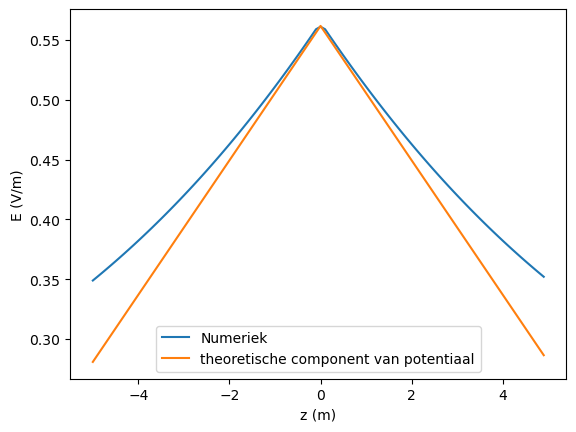

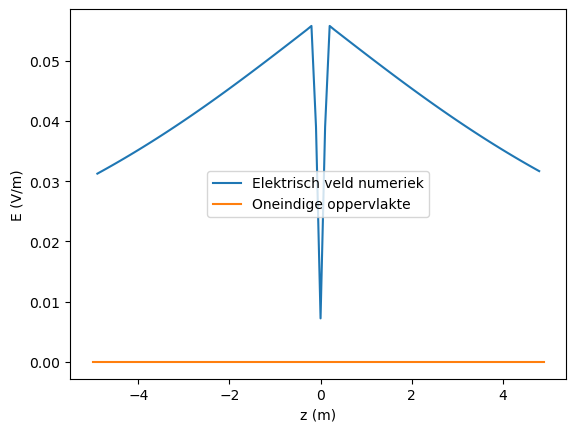

In [88]:
#mid_r = V.shape[0] // 2
mid_r = np.argmin(np.abs(r))
print(mid_r)
R = disk_radius
V_z = V[:, mid_r] 

def grootPot(z):
    return (sigma/(2*epsilon0)) * (R - np.abs(z))


plt.figure()
plt.plot(z,V_z, label="Numeriek")
plt.plot(z,grootPot(z), label="theoretische component van potentiaal")
plt.xlabel("z (m)")
plt.ylabel("E (V/m)")
plt.legend()
plt.savefig("theoretische_potenciaal_R10.png", dpi=300)

plt.show()


mid_z = normE.shape[1] // 2
Eoneindig = ladingsdichtheid/(2*epsilon0)
Eoneindig_array =np.array([])

E_z_on = np.linspace(min(z),max(z),1000)
Eoneindig_array = np.full(len(E_z_on), Eoneindig)


E_z = normE[:, mid_z] 

plt.plot(z_for_E,E_z,label="Elektrisch veld numeriek")
plt.plot(E_z_on,Eoneindig_array,label="Oneindige oppervlakte")
plt.xlabel("z (m)")
plt.ylabel("E (V/m)")
plt.legend()
plt.savefig("theoretische_potenciaal_R10_plaat.png", dpi=300)
plt.show()

##### Antwoorden 2g


We zien bij de eerste figuur dat het theoretisch model nu meer overeenkomt met het numeriek model, De theoretische formule is accuraat voor R>>z dus als R groter word zal het bereik van z numeriek die overeenkomt met z theoretisch groter worden.

Bij het tweede figuur zien we een verklaarbaar gedrag. het elektrisch veld neemt af naar mate de straal toeneemt. Bij een oneindig oppervlak zal deze gelijk blijven omdat de lading uniform is verdeeld. De dip in het nulpunt is ook te verklaren. Als we kijken naar de eerste plaatjes (van het vectorveld) van opgave 2, zien we dat het veld aan de andere kant van de plaat de andere kant op gaat wijzen. Alleen er is waarschijnlijk de absolute waarde van de potenciaal genomen waardoor je zo een grafiek met een knik krijgt. Bij die knik zit je dus in die plaat.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h
![figure 5.1](figures/UitwerkingThuisopdr1.jpeg)

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

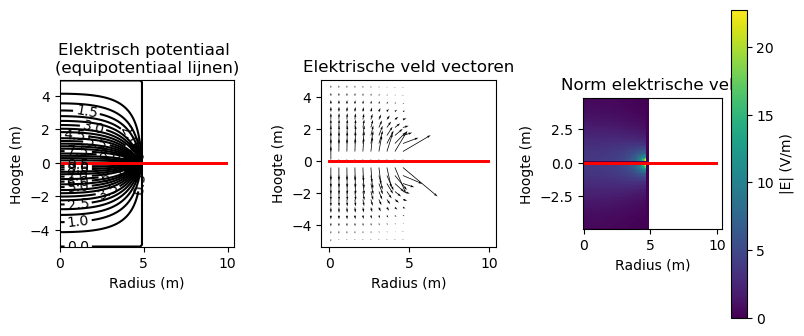

In [89]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

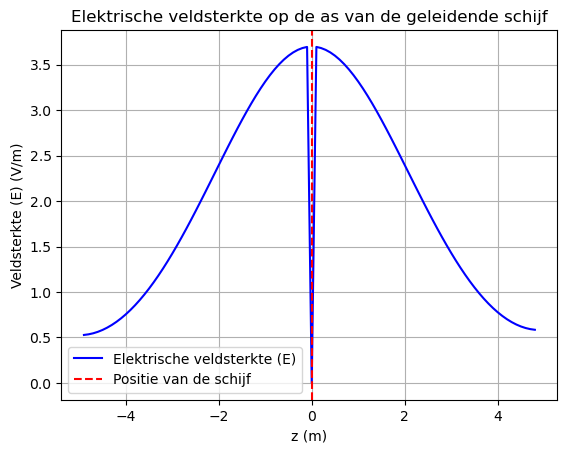

De veldsterkte E op de as nabij het midden is E = 6.0411e-05 V/m


In [13]:
# 1. Plot de elektrische veld sterkte op de as van de schijf 
# r = 0 dus de eerste kolom van normE 
E_on_axis = normE[:, 0] 

plt.figure()
plt.plot(z_for_E, E_on_axis, label='Elektrische veldsterkte (E)', color='blue')
plt.axvline(x=z_pos_disk1, color='red', linestyle='--', label='Positie van de schijf')

plt.xlabel('z (m)')
plt.ylabel('Veldsterkte (E) (V/m)')
plt.title('Elektrische veldsterkte op de as van de geleidende schijf')
plt.legend()
plt.grid(True)
plt.show()

# 2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak. 
# We zoeken de index in z_for_E die het dichtst bij z_pos_disk1 ligt
idx_center_z = np.argmin(np.abs(z_for_E - z_pos_disk1))
E_near_center = E_on_axis[idx_center_z]
print(f"De veldsterkte E op de as nabij het midden is E = {E_near_center:.4e} V/m")


#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

De totale oppervlaktelading in het midden van een dunne geleidende schijf wordt benaderd door:

$$\sigma_{midden} = 2 \cdot \epsilon_0 \cdot E_{z,oppervlak}$$

Waarbij:
* **$\sigma_{midden}$** is de totale lading per oppervlakte-eenheid ($C/m^2$).
* **$2$** is de factor die aangeeft dat de schijf twee zijden (boven en onder) heeft die bijdragen aan de totale ladingsdichtheid.
* **$\epsilon_0$** is de vacuümpermittiviteit.
* **$E_{z,oppervlak}$** is de z-component van het elektrisch veld vlak boven het oppervlak van de schijf op de centrale as.

In [14]:
# Constanten
epsilon_0 = 8.8541878128e-12  # Vacuümpermittiviteit (F/m)

# Pak de waarde van Ez op de as (r=0) vlak bij de schijf, dus weer de eerder bepaalde idx_center_z
# Absolute waarde omdat sigma de dichtheid aangeeft en dus niet negatief kan zijn
E_surface = np.abs(Ez[idx_center_z, 0])

# Berekening van de oppervlaktelading sigma
sigma_midden = 2 * epsilon_0 * E_surface

print(f"Benadering van de oppervlakte lading in het midden van de schijf is: {sigma_midden:.4e} C/m^2")

Benadering van de oppervlakte lading in het midden van de schijf is: 1.0698e-15 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


De berekende totale lading Q is: 6.7217e-13 C
Sigma midden voor de geleidende schijf is:  1.0698e-15 C/m^2
Sigma midden voor de uniforme schijf is:  1.0698e-15 C/m^2
De oppervlaktelading voor sigma in het midden is dus hetzelfde voor een uniforme als voor een geleidende schijf. 


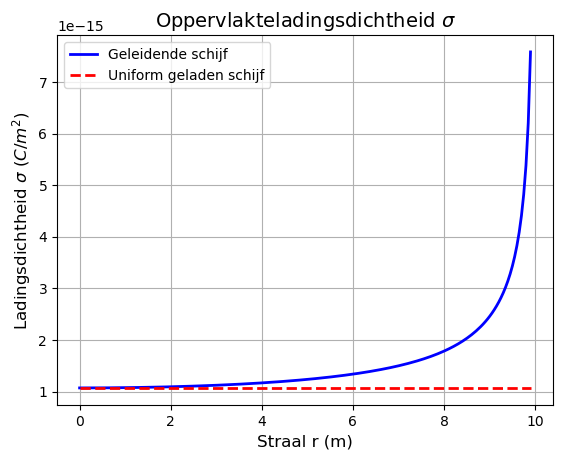

In [92]:
# 1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
R = disk_radius
# totale lading is ladingsdichtheid * 2 keer het oppervlakte
Q_totaal = sigma_midden * (2 * np.pi * R**2)

print(f"De berekende totale lading Q is: {Q_totaal:.4e} C")

# 2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
# array 
r_as = np.linspace(0, R * 0.99, 200) # net voor de rand stoppen want geen 0 in de wortel

# Geleidende schijf
sigma_geleidend = Q_totaal / (2 * np.pi * R * np.sqrt(R**2 - r_as**2))

# Uniform geladen schijf
sigma_waarde = Q_totaal / (2*np.pi * R**2)

# even lang maken als r_as
sigma_uniform = np.ones(len(r_as)) * sigma_waarde

print(f"Sigma midden voor de geleidende schijf is:  {sigma_midden:.4e} C/m^2")
print(f"Sigma midden voor de uniforme schijf is:  {sigma_uniform[0]:.4e} C/m^2")
print("De oppervlaktelading voor sigma in het midden is dus hetzelfde voor een uniforme als voor een geleidende schijf. ")

# 3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading Q, tussen r = 0 en R.
# 4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$
plt.figure()
plt.plot(r_as, sigma_geleidend, label='Geleidende schijf', color='blue', linewidth=2)
plt.plot(r_as, sigma_uniform, label='Uniform geladen schijf', color='red', linestyle='--', linewidth=2)
plt.title(r'Oppervlakteladingsdichtheid $\sigma$', fontsize=14)
plt.xlabel('Straal r (m)', fontsize=12)
plt.ylabel(r'Ladingsdichtheid $\sigma$ ($C/m^2$)', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [94]:
# 1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
e_max = np.max(normE)

# 2. Bepaal waar in de ruimte dit maximum zich bevindt.
# We zoeken de indices (z, r) van de hoogste waarde
idx_z_max, idx_r_max = np.unravel_index(np.argmax(normE), normE.shape)

# Vertaal de indices terug naar fysieke coördinaten
r_max_coord = r_for_E[idx_r_max]
z_max_coord = z_for_E[idx_z_max]

# 3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
e_midden = E_surface 
factor_hoger = e_max / e_midden

# 4. Print met een nette opmaak de waardes die je hier hebt berekend.
print(f"Het maximum van het elektrisch veld van de geleidende schijf is: {e_max:.4e} V/m")
print(f"De locatie van het maximum is: r = {r_max_coord:.3f} m, z = {z_max_coord:.3e} m")
print(f"Het elektrisch veld in het midden is: {e_midden:.4e} V/m")
print(f"Het veld bij de rand is {factor_hoger:.2f} keer zo sterk als in het midden.")

Het maximum van het elektrisch veld van de geleidende schijf is: 2.2768e+01 V/m
De locatie van het maximum is: r = 4.700 m, z = 2.000e-01 m
Het elektrisch veld in het midden is: 6.0411e-05 V/m
Het veld bij de rand is 376880.11 keer zo sterk als in het midden.


##### Antwoord 3d.5

In een geleidende shijf kunnen ladingen vrij bewegen. Gelijke ladingen stoten elkaar af en onderhouden dus een zo groot mogelijke afstand van elkaar, daardoor verplaatst de lading zich naar de rand en is de veldsterkte daar zo hoog.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

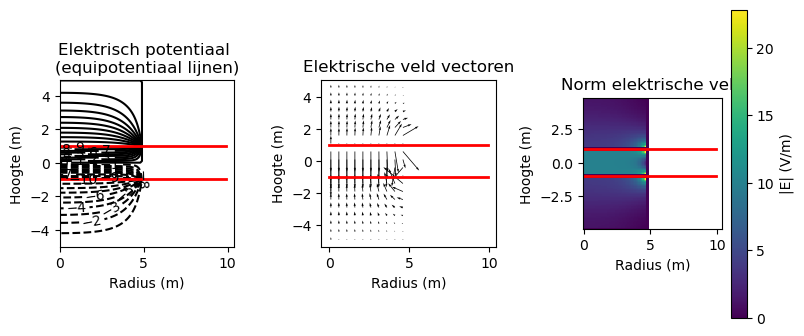

In [95]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


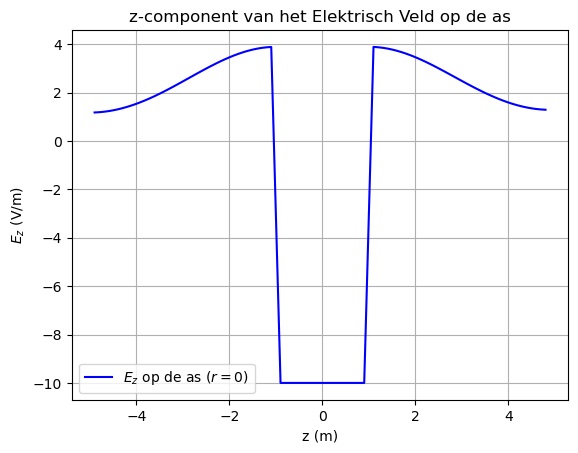

In [18]:
# 1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijven.

# Bepaal de index voor de as (r = 0)
idx_as = np.argmin(np.abs(r_for_E))

#Selecteer de Ez waarden op deze as
Ez_op_as = Ez[:, idx_as]

# Plotten
plt.figure()
plt.plot(z_for_E, Ez_op_as, label='$E_z$ op de as ($r=0$)', color='blue')
plt.title('z-component van het Elektrisch Veld op de as')
plt.xlabel('z (m)')
plt.ylabel('$E_z$ (V/m)')
plt.grid(True)
plt.legend()
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b
1. Het potentiaal tussen twee geleidende platen kan bererkend worden met de volgende formule:

Aangezien $\vec{E} = -\Delta V$, volgt de volgende afleiding:
$$E_z = -\frac{dV}{dz} = -\frac{V_1 - (-V_1)}{d} = -\frac{2V_1}{d}$$
![alt text](<figures/WhatsApp Image 2026-03-05 at 10.13.32.jpeg>)

2. In het numeriek berekende elektrische veld is het veld constant, wat exact overeenkomt met de theorie. Direct buiten de platen verandert het elektrische veld heel snel, wat volgens de theorie ook klopt, maar verder buiten de platen is $E_z$ niet 0 maar gaat langzaam naar 0. Dit komt niet overeen met de theorie maar kan komen doordat de theorie uitgaat van een oneindig grote plaat en deze platen dat niet zijn.

3. Bij een schijf neemt het veld snel af als de afstand tot de schijf groter wordt en is het elektrische veld niet uniform. Het voordeel van het hebben van 2 geleidende platen is dus het hebben van een uniform elektrisch veld tussen de platen.


#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [19]:
#1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
# Elektrisch veld tussen platen (E=2*V_1/d)
E = 2*V1/spacing_between_disks

# Oppervlakteladingsdichtheid
sigma = epsilon0 * E

# Oppervlakte van een schijf
A = np.pi * disk_radius**2

# lading op één plaat
Q_plaat = sigma * A


# 2. Bepaal de verwachte totale lading op beide schijven.
# totale lading op beide platen (absolute waarde)
Q_totaal = 2 * Q_plaat


# 3. Bepaal de capaciteit van deze situatie.

# Potentiaalverschil
deltaV = V1 - V2

# Capaciteit
C = Q_plaat / deltaV

#4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

print(f"De oppervlakte lading op één plaat is:              {Q_plaat:.3e} C")
print(f"De totale oppervlakte lading op beide platen is:    {Q_totaal:.3e} C")
print(f"De capaciteit van deze situatie is:                 {C:.3e} F")

De oppervlakte lading op één plaat is:              2.782e-08 C
De totale oppervlakte lading op beide platen is:    5.563e-08 C
De capaciteit van deze situatie is:                 1.391e-09 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1. In een ideale situatie met oneindig grote schijven zou de oppervlaktelading aan de buitenkant 0 zijn, aangezien de velden elkaar dan altijd precies zouden opheffen aan de buitenkanten. In een realistische situatie met eindige schijven zal dit niet het geval zijn aangezien er aan de zijkanten van de platen randvelden zullen ontstaan. Om dit mogelijk te maken moet er dus wel een kleine lading op de buitenkant van de schijven zitten.

2. Het elektrische veld nabij het oppervlak van een geleider valt te beschrijven door de onderstaande formule voor de ladingsdichtheid op een geleider in te vullen bij de daaronder staande formule voor het elektrisch veld.

$$E = \frac{\sigma}{\epsilon_0}$$


#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
#1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
idx_onder = np.argmin(np.abs(z_for_E - (z_pos_disk2 - grid_step)))
Ez_onder = Ez[idx_onder, idx_as]

#2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
sigma_onder = -epsilon0 * Ez_onder

#3. Welke waarde heeft het z-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
idx_boven = np.argmin(np.abs(z_for_E - (z_pos_disk2 + grid_step)))
Ez_boven = Ez[idx_boven, idx_as]

# 4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
sigma_boven = epsilon0 * Ez_boven

#5. Print de bepaalde waardes op een nette en overzichtelijke manier.
print(f"Het elektrische veld net onder de onderste schijf is:           {Ez_onder:10.3e} V/m")
print(f"De ladingsdichtheid aan de onderkant van de onderste schijf is: {sigma_onder:10.3e} C/m^2")
print(f"Het elektrische veld net boven de onderste schijf is:           {Ez_boven:10.3e} V/m")
print(f"De ladingsdichtheid aan de bovenkant van de onderste schijf:    {sigma_boven:10.3e} C/m^2")

Het elektrische veld net onder de onderste schijf is:            3.888e+00 V/m
De ladingsdichtheid aan de onderkant van de onderste schijf is: -3.442e-11 C/m^2
Het elektrische veld net boven de onderste schijf is:           -1.000e+01 V/m
De ladingsdichtheid aan de bovenkant van de onderste schijf:    -8.854e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. De daadwerkelijke lading op de schijf is hoger dan de berekende waarde bij vraag 4c, omdat er in het numerieke model ook een klein elektrisch veld aan de buitenkant van de schijven staat.
2. Doordat de daadwerkelijke lading op de schijf hoger is is de werkelijke capaciteit dus ook groter dan de theoretische capaciteit door het grotere potentiaalverschil.
3. Door de kleinere afstand is de elektrische veldsterkte tussen de platen groter en wordt de lading buiten de platen kleiner. De capaciteit neemt dus ook toe.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [21]:
def vlakkeplaat(epsilon_r,A,d):
    C = epsilon0*epsilon_r * (A/d)
    return C

def cilinder(epsilon_r,L,b,a):
    C = 2*np.pi * epsilon0 * epsilon_r * L /(b - a)
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [22]:
waarde_1 = vlakkeplaat(1,0.10*0.10,0.001)
print(f"De capaciteit bij vraag 1 is: {waarde_1:.13f} Farads")

waarde_2 = cilinder(1,0.10,0.010,0.009)
print(f"De capaciteit bij vraag 2 is: {waarde_2:.13f} Farads")

waarde_3a = vlakkeplaat(1,0.10*0.10,0.002)
print(f"De capaciteit bij vraag 3a is: {waarde_3a:.13f} Farads")

waarde_3b = cilinder(1,0.10,0.020,0.018)
print(f"De capaciteit bij vraag 3b is: {waarde_3b:.13f} Farads")

waarde_4a = vlakkeplaat(79,0.10*0.10,0.001)
print(f"De capaciteit bij vraag 4a is: {waarde_4a:.13f} Farads")

waarde_4b = cilinder(79,0.10,0.010,0.009)
print(f"De capaciteit bij vraag 4b is: {waarde_4b:.13f} Farads")

waarde_5a = vlakkeplaat(3,0.10*0.10,0.001)
print(f"De capaciteit bij vraag 5a is: {waarde_5a:.13f} Farads")

waarde_5b = cilinder(3,0.10,0.010,0.009)
print(f"De capaciteit bij vraag 5b is: {waarde_5b:.13f} Farads")

De capaciteit bij vraag 1 is: 0.0000000000885 Farads
De capaciteit bij vraag 2 is: 0.0000000055631 Farads
De capaciteit bij vraag 3a is: 0.0000000000443 Farads
De capaciteit bij vraag 3b is: 0.0000000027816 Farads
De capaciteit bij vraag 4a is: 0.0000000069947 Farads
De capaciteit bij vraag 4b is: 0.0000004394874 Farads
De capaciteit bij vraag 5a is: 0.0000000002656 Farads
De capaciteit bij vraag 5b is: 0.0000000166894 Farads


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [23]:
C = 1e-6
a = 2.5e-3
b = 3.0e-3
d =0.5e-3
#lengte bereken door formule om te schrijven
L = (C*np.log(b/a))/(2*np.pi*epsilon0)
Opp = C * d/epsilon0
zijde = np.sqrt(Opp) # wortel trekken voor zeide

print(f"De lengte bij vraag 1 is: {L:.13f} m")
print(f"De zijde bij vraag 2 is: {zijde:.13f} m")


De lengte bij vraag 1 is: 3277.3183867142097 m
De zijde bij vraag 2 is: 7.5147622205285 m


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
De antwoorden zijn niet realistisch, kijkend naar het plaatje kan de condensator niet 3 km lang zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.
Door een materiaal te gebruiken tussen de condensatorplaten, hierdoor word de noemer groter waardoor de lengte kleiner word.

##### Antwoorden 5d


1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
De antwoorden zijn niet realistisch, de waardes zijn namelijk veel te hoog. De cilinder condensator kan kijkend naar het plaatje geen 3 kilometer lang zijn en ook een vlakke plaat condensator van 7 meter is onrealistisch.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.
Door een materiaal te gebruiken tussen de condensatorplaten, hierdoor wordt de $\epsilon_r$ in de noemer groter waardoor de lengte kleiner wordt.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [24]:
v = 70/3.6  #snelheid in m/s
m = 6* 70 + 1200    #6 mensen van 70 kg + een karretje van 1200 kg
V = 10000   #V
epsilonr = 80   #permitiviteit van water
epsilon0 = 8.854e-12
d = 1e-3        #dikte van de platen in meter
# E_k = E dus
#Kinetische energie
E = 0.5 * m * v**2

#Capaciteit door energie
C = 2*E/V**2

#formule voor het berekenen van het oppervlakte
A = C * d/ (epsilon0 * epsilonr)

print(f"De totale energie van het treintje na het afschieten is: {E:.5f} J")
print(f"De tote capiciteit van de condensator is: {C:.5f} F")
print(f"De totale oppervlakte van de vlakke plaat condensator gevuld met water is: {A:.5f} m^2")


De totale energie van het treintje na het afschieten is: 306250.00000 J
De tote capiciteit van de condensator is: 0.00612 F
De totale oppervlakte van de vlakke plaat condensator gevuld met water is: 8647.22159 m^2


##### Antwoorden 5e
Dit antwoord is totaal onrealistisch, een condensator met een oppervlakte van 8000 vierkante meter zal niet bestaan.

Dit zou mischien kunnen door de condensator te vouwen en op te rollen of door de afstand tussen de platen te verkleinen, het oppervlakte wordt met dezelfde factor kleiner als het oppervlakte. Verder zou er gebruikgemaakt kunnen worden van een ander materiaal met een grotere $\epsilon_r$ waarde.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

<function matplotlib.pyplot.show(close=None, block=None)>

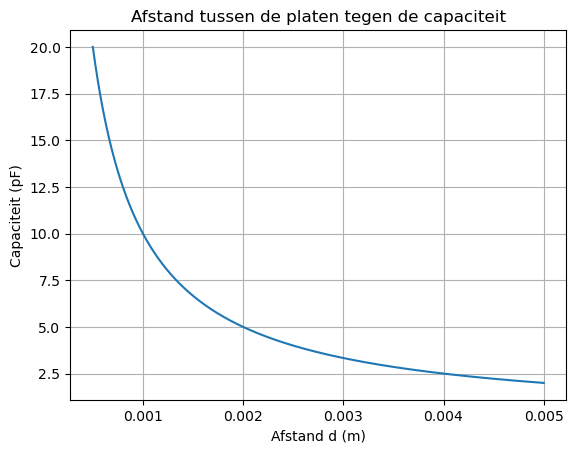

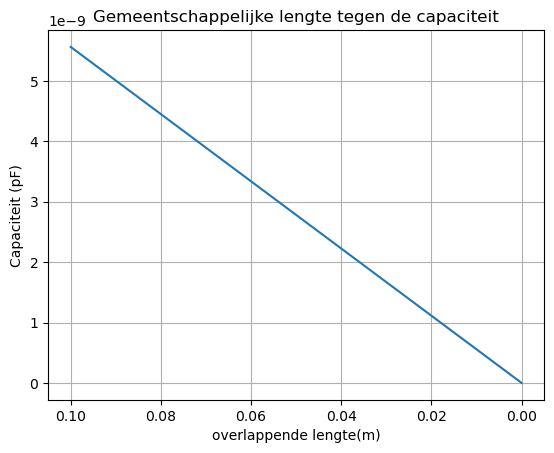

In [35]:
#array van 0.5 mm tot 5 mm
afstandplaat = np.linspace(0.0005,0.005,1000)

#berekenen van de bijbehorende capaciteit A = 0.01, epsilon_r = 1 en d is de array afstandplaat
Fvlak = vlakkeplaat(1,0.01,afstandplaat)

plt.figure()
plt.title("Afstand tussen de platen tegen de capaciteit")
plt.plot(afstandplaat,Fvlak)
plt.xlabel("Afstand d (m)")
plt.ylabel("Capaciteit (pF)")
plt.grid()
plt.show

#array van 10 mm tot 10 cm
Lcilinders = np.linspace(0.1,0,1000)

#berekenen van de capaciteit epsilon_r = 1, L is de array van 10 mm tot 10 cm, b = 10 mm en a = 9 mm
Fcilinder = cilinder(1,Lcilinders,10e-3,9e-3)

plt.figure()
plt.title("Gemeentschappelijke lengte tegen de capaciteit")
plt.plot(Lcilinders,Fcilinder)
plt.xlabel("overlappende lengte(m)")
plt.ylabel("Capaciteit (pF)")
plt.gca().invert_xaxis()
plt.grid()
plt.show

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

![figure 5.1](figures/sensoren_in_actie.jpg.jpeg)

![figure 5.1](figures/Schets_opstelling.jpeg)

In [26]:
##Oorspronkelijke functie


epsilon0 = 8.8541878188*10**-12
epsilon_water = 80
epsilon_lucht = 1.00056
A = 0.1**2
d = 0.00101
totaal_volume = A * d 
volumes_verwacht = np.linspace(0,totaal_volume, 30)

def vlakkeplaat(epsilon, A,l):
    C = (A*epsilon)/l
    return C

def epsilon_verwacht(V):
    return (V/totaal_volume)*epsilon_water + (1-V/totaal_volume)*epsilon_lucht

c = epsilon0*epsilon_verwacht(volumes_verwacht)*A/d  

1.0100000000000003e-05


C:\Users\Jasper Bom\AppData\Local\Temp\ipykernel_19064\2210065059.py:24: RuntimeWarning: divide by zero encountered in divide
  (2*d_plastic)/(epsilon0*epsilon_p*A_water) +
C:\Users\Jasper Bom\AppData\Local\Temp\ipykernel_19064\2210065059.py:25: RuntimeWarning: divide by zero encountered in divide
  (d_medium)/(epsilon0*epsilon_water*A_water)
C:\Users\Jasper Bom\AppData\Local\Temp\ipykernel_19064\2210065059.py:29: RuntimeWarning: divide by zero encountered in divide
  (2*d_plastic)/(epsilon0*epsilon_p*A_lucht) +
C:\Users\Jasper Bom\AppData\Local\Temp\ipykernel_19064\2210065059.py:30: RuntimeWarning: divide by zero encountered in divide
  (d_medium)/(epsilon0*epsilon_lucht*A_lucht)


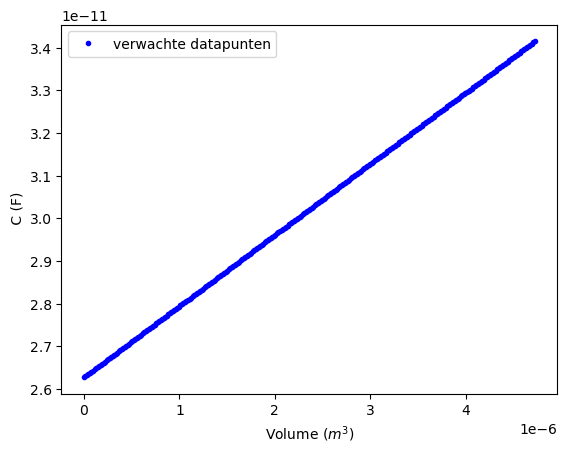

In [ ]:
## Hermaakte code met epsilon plactic meegenomen.
epsilon0 = 8.8541878188*10**-12
epsilon_water = 80
epsilon_lucht = 1.00056
lengte = 0.087 
hoogte = 0.089
A = lengte *hoogte
d_total = 0.00101
## epsilon plastic wanden gezocht
epsilon_p = 0.2
d_plastic = 0.0002
d_medium = d_total - 2*d_plastic
V_max = lengte*hoogte*d_medium

volumes_verwacht = np.linspace(0,V_max, 300)
## Nu word de uiteindelijke epsilon accurater omdat epsilon plastic word meegerekend.
## De onderstaande functie neemt het plastic mee in de berekening
def capaciteit_bij_vulling(Vwater):
    d_medium = d_total - 2*d_plastic
    V_max = lengte*hoogte*d_medium
    A_water = Vwater/d_medium
    C_water = 1 / (
        (2*d_plastic)/(epsilon0*epsilon_p*A_water) +
        (d_medium)/(epsilon0*epsilon_water*A_water)
    )
    A_lucht = (V_max - Vwater)/d_medium
    C_lucht = 1 / (
        (2*d_plastic)/(epsilon0*epsilon_p*A_lucht) +
        (d_medium)/(epsilon0*epsilon_lucht*A_lucht)
    )
    
    return C_water + C_lucht
C = capaciteit_bij_vulling(volumes_verwacht)


##print(f"Berekende capaciteit plaatcondensator groep 8 is {C:.2e} F")
##print(f'Gemeten waarde via oscilloscoop aflezen is 1.90e-10 F ')

plt.figure()
plt.plot(volumes_verwacht, C, 'b.', label="verwachte datapunten")
plt.legend()
plt.xlabel(r"Volume $(m^3)$")
plt.ylabel(r" C (F)") 
plt.show()

2.5053101306935684e-06


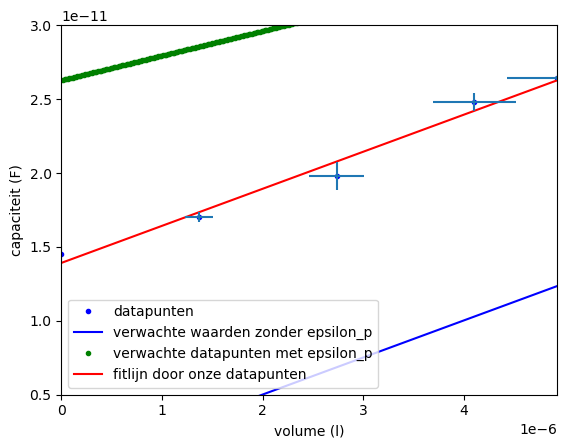

In [28]:
## Hier zijn de lijnen geplot
from scipy.optimize import curve_fit
Inhoud = lengte * hoogte * d_total
capaciteit = np.array([14.5,17.0,19.8,24.8,26.4])*10**-12
volume = np.array([0,0.25,0.5,0.75,0.9])*(Inhoud*0.7)

def function(x,a,b):
    return a*x+b


values, covariance = curve_fit(function, volume, capaciteit)
x_fit = np.linspace(0, max(volume), 300)
y_fit = function(x_fit,*values)
print(values[0])

capaciteit_err = np.abs(function(volume,*values)-capaciteit)
volume_err = 0.1 * volume

verwacht_volume = c/values[0]
v_verwacht = np.array([verwacht_volume[0],verwacht_volume[10],verwacht_volume[-1]])
C_verwacht = np.array([c[0],c[10],c[-1]])
popt, pcov = curve_fit(function,v_verwacht,C_verwacht)
x_nieuw = np.linspace(0,max(v_verwacht),300)

plt.figure()
plt.plot(volume, capaciteit,'b.', label = 'datapunten')
plt.plot(x_nieuw, function(x_nieuw,*popt),'b-', label = 'verwachte waarden zonder epsilon_p')
plt.xlim(0,max(volume+0.5*10**-8))
plt.ylim(0.5e-11,0.3e-10)
plt.plot(volumes_verwacht, C, 'g.', label="verwachte datapunten met epsilon_p")
plt.plot(x_fit,y_fit,'r-', label = 'fitlijn door onze datapunten')
plt.errorbar(volume,capaciteit,capaciteit_err,volume_err, fmt = 'none')
plt.xlabel(r'volume (l)')
plt.ylabel(r'capaciteit (F)')
plt.legend()
plt.show()

Opvallend is dat de groene lijn juist een stuk boven de metingen ligt. Een mogelijke verklaring kan zijn dat de epsilon_p en de dikte van het plastic plaatje geschat zijn. 

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [29]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [30]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

Als je naar de grafiek kijkt verklaart de meename van plastic niet veel. Tussen de platen kan het veld niet helemaal loodrecht zijn. De platen kunnen schuin tegen elkaar zijn gezet waardoor het elektisch veld minder sterk is dan verwacht. Ook hierdoor kan het elektisch veld aan de randen gaan krommen waardoor het elektrisch veld minder sterk is dan verwacht. Doordat de platen van de capacitor niet zo groot zijn ontstaat er een klein elektrisch veld langs de randen, hierdoor is het elektrische veld dus iets kleiner en daarmee de capaciteit ook iets kleiner. 